In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pickle

In [29]:
# 1. Generate Synthetic 'Risk' Data
np.random.seed(42)
n_games = 2000
targets = np.random.randint(2, 13, n_games)
luck = np.random.uniform(1, 10, n_games)
# A 'Win' (1) occurs if the target matches a random dice sum
wins = [1 if (random.randint(1, 6) + random.randint(1, 6)) == t else 0 for t in targets]

In [30]:
df = pd.DataFrame({'target': targets, 'luck': luck, 'win': wins})

In [32]:
# 2. Train/Test Split (Standard Practice)
X = df[['target', 'luck']]
y = df['win']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# 3. Implementation of GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Model Accuracy: 0.9225
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       369
           1       0.00      0.00      0.00        31

    accuracy                           0.92       400
   macro avg       0.46      0.50      0.48       400
weighted avg       0.85      0.92      0.89       400



C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


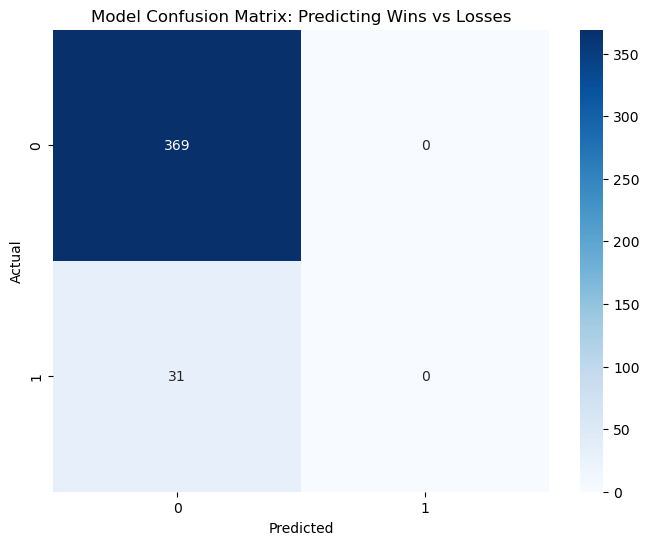

In [34]:
# 4. Professional Evaluation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Model Confusion Matrix: Predicting Wins vs Losses')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png') # Save this for your README!

print(f"Model Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

In [36]:
# 5. Save Model
with open('dice_model.pkl', 'wb') as f:
    pickle.dump(model, f)

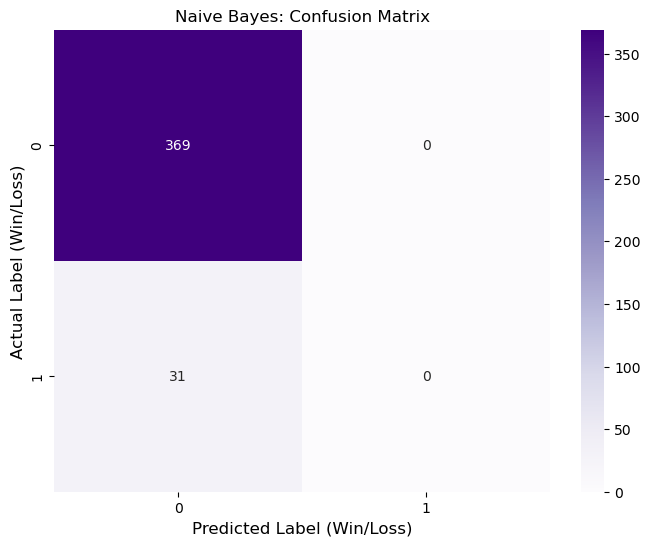

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# 2. Create the visual
plt.figure(figsize=(8, 6), facecolor='white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

# 3. Add professional labels for HR to see
plt.title('Naive Bayes: Confusion Matrix')
plt.xlabel('Predicted Label (Win/Loss)', fontsize=12)
plt.ylabel('Actual Label (Win/Loss)', fontsize=12)

# 4. CRITICAL STEP: Save the file to your project folder
plt.savefig('confusion_matrix.png', bbox_inches='tight', transparent=False, facecolor='white')
plt.show()